# Globally Interconnected Solar-Wind System — 输入数据可视化 & 最优解提取

对应论文：*Globally Interconnected Solar-Wind System Addresses Future Electricity Demands* (Jiang et al., Nat. Commun. 2025)

**使用说明**
- Section 0：环境配置，修改 `DATA_DIR` 和 `RESULT_FILE` 指向你的真实数据
- Section 1–6：逐一可视化每类输入数据
- Section 7：从优化结果中提取最优解并可视化场站位置
- 若真实数据尚未就绪，代码会自动生成与真实数据同结构的模拟数据，方便调试

---
## Section 0 — 环境配置与路径设置

字体名称: Source Han Sans SC


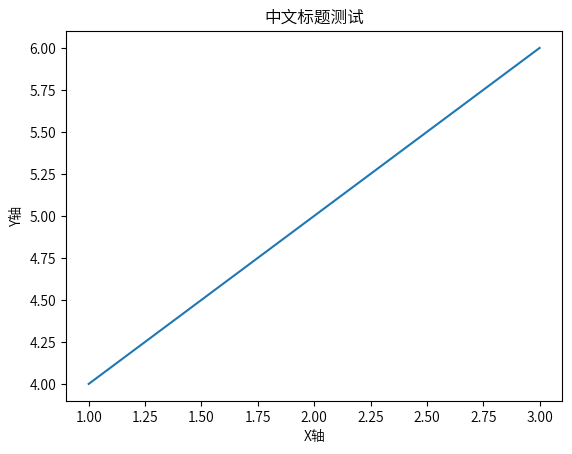

In [3]:
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

# 指定字体文件路径
font_path = "/data4/yanxiaokai/SourceHanSansSC-Normal.otf"  # Linux 示例路径

# 关键：使用 addfont 将字体添加到 fontManager
fm.fontManager.addfont(font_path)

# 获取字体名称（不是文件名！）
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()
print(f"字体名称: {font_name}")

# 设置全局字体
plt.rcParams['font.family'] = [font_name]
plt.rcParams['axes.unicode_minus'] = False

# 测试
plt.plot([1, 2, 3], [4, 5, 6])
plt.title('中文标题测试')
plt.xlabel('X轴')
plt.ylabel('Y轴')
plt.show()

In [ ]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib import font_manager as fm
import h5py
import scipy.io

# 指定字体文件路径
font_path = "/data4/yanxiaokai/SourceHanSansSC-Normal.otf"
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)  # 获取字体名称
font_name = font_prop.get_name()
print(f"字体名称: {font_name}")

# 设置全局字体
plt.rcParams["font.family"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False


import rasterio
import cartopy.crs as ccrs
import cartopy.feature as cfeature

HAS_RASTERIO = True
HAS_CARTOPY = True

print(f"rasterio: {HAS_RASTERIO}, cartopy: {HAS_CARTOPY}")

# ============================================================
# ★ 修改以下路径指向你的真实数据目录
# ============================================================
DATA_DIR = "./Optimization"  # 输入数据目录
RESULT_FILE = "Resilience/Optimization_SG_2050_Res.h5"  # 优化结果 HDF5 文件
USE_MOCK = True  # True = 使用模拟数据；False = 读取真实数据
# ============================================================

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    }
)

# 20 个区域标签（与论文 Fig. S4 对应）
REGION_NAMES = [
    "Northern America",
    "Caribbean",
    "Central America",
    "Southern America",
    "Northern Europe",
    "Western Europe",
    "Southern Europe",
    "Eastern Europe",
    "Central Asia",
    "Eastern Asia",
    "Southern Asia",
    "Southeastern Asia",
    "Western Asia",
    "Australia-NZ",
    "Melanesia",
    "Northern Africa",
    "Western Africa",
    "Middle Africa",
    "Eastern Africa",
    "Southern Africa",
]

print("配置完成")

字体名称: Source Han Sans SC
rasterio: True, cartopy: True
配置完成


---
## Section 1 — 风电适宜性栅格 (`Global_Wind_Net_Area_Add_Egrid.tif`)

**含义**：每个 500m 像元中可安装风机的净面积占比（%），由土地覆被 + 坡度 + 道路距离 + 输电线距离四重筛选后得到


  Global_Wind_Net_Area_Add_Egrid (风电适宜性 %)
  Shape        : (180, 360)
  Lon 范围     : [-180.00°, 180.00°]
  Lat 范围     : [-90.00°, 90.00°]
  全域值域     : [0.0000, 9.9957]
  非零像元数   : 8,477
  非零均值     : 3.0856
  非零中位数   : 2.0992
  非零标准差   : 2.9292


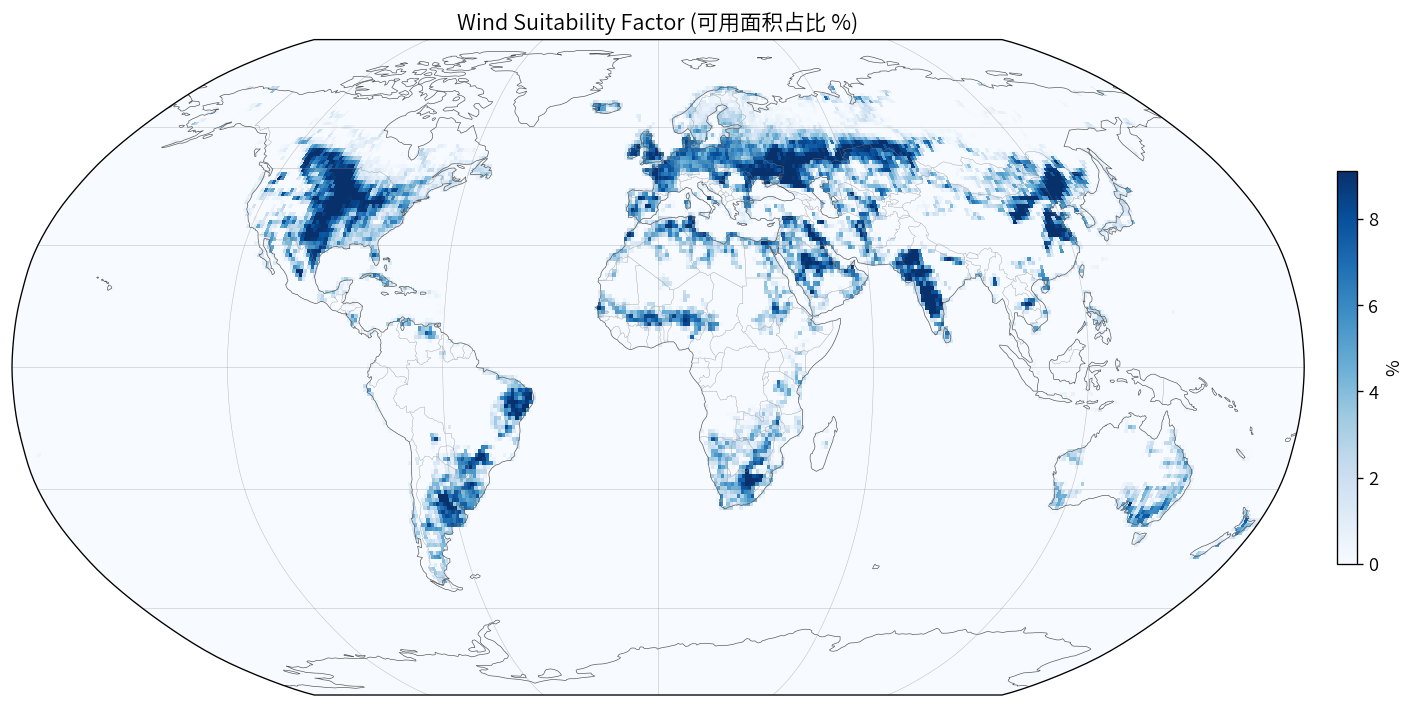

In [7]:
def load_or_mock_tif(filepath, mock_shape=(720, 1440), mock_range=(0, 100),
                      mock_nodata=0, dtype=np.float32):
    """读取 GeoTIFF；若文件不存在则返回模拟数据和伪空间参考"""
    if HAS_RASTERIO and os.path.exists(filepath):
        with rasterio.open(filepath) as src:
            data = src.read(1).astype(np.float64)
            bounds = src.bounds          # left, bottom, right, top
            transform = src.transform
            nodata = src.nodata
            if nodata is not None:
                data[data == nodata] = np.nan
        lon = np.linspace(bounds.left, bounds.right, data.shape[1])
        lat = np.linspace(bounds.top,  bounds.bottom, data.shape[0])
        return data, lon, lat, True
    else:
        print(f'  [MOCK] {filepath} 未找到，使用模拟数据')
        np.random.seed(42)
        data = np.random.uniform(*mock_range, size=mock_shape).astype(np.float64)
        # 模拟陆地/海洋掩膜：高纬度和极地设为 0
        data[:50, :]  = 0
        data[-50:, :] = 0
        data[data < mock_range[0] + (mock_range[1]-mock_range[0])*0.7] = 0  # 稀疏
        lon = np.linspace(-180, 180, mock_shape[1])
        lat = np.linspace(90, -90, mock_shape[0])
        return data, lon, lat, False


def print_stats(name, data, lon, lat):
    valid = data[np.isfinite(data) & (data > 0)]
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Shape        : {data.shape}")
    print(f"  Lon 范围     : [{lon.min():.2f}°, {lon.max():.2f}°]")
    print(f"  Lat 范围     : [{lat.min():.2f}°, {lat.max():.2f}°]")
    print(f"  全域值域     : [{np.nanmin(data):.4f}, {np.nanmax(data):.4f}]")
    print(f"  非零像元数   : {len(valid):,}")
    print(f"  非零均值     : {valid.mean():.4f}")
    print(f"  非零中位数   : {np.median(valid):.4f}")
    print(f"  非零标准差   : {valid.std():.4f}")


def plot_global_map(ax, data, lon, lat, title, cmap='YlOrRd', vmax=None,
                    cbar_label='', is_mock=False):
    if HAS_CARTOPY:
        ax.set_global()
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4, color='#555')
        ax.add_feature(cfeature.BORDERS,   linewidth=0.2, color='#888')
        ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5)
        lon2d, lat2d = np.meshgrid(lon, lat)
        vm = vmax if vmax else np.nanpercentile(data[data>0], 95) if np.any(data>0) else 1
        im = ax.pcolormesh(lon2d, lat2d, data, cmap=cmap,
                           vmin=0, vmax=vm, transform=ccrs.PlateCarree(),
                           rasterized=True)
    else:
        vm = vmax if vmax else np.nanpercentile(data[data>0], 95) if np.any(data>0) else 1
        im = ax.imshow(data, cmap=cmap, vmin=0, vmax=vm,
                       extent=[lon.min(), lon.max(), lat.min(), lat.max()],
                       aspect='auto', origin='upper')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
    plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02, label=cbar_label)
    suffix = ' [MOCK]' if is_mock else ''
    ax.set_title(title + suffix, fontweight='bold')


# --- 加载数据 ---
wind_net, wlon, wlat, wind_real = load_or_mock_tif(
    os.path.join(DATA_DIR, 'Global_Wind_Net_Area_Add_Egrid.tif'),
    mock_shape=(720, 1440), mock_range=(0, 100)
)
wind_net_pct = wind_net / 100.0   # 转为小数（与 MATLAB 代码一致）

print_stats('Global_Wind_Net_Area_Add_Egrid (风电适宜性 %)', wind_net, wlon, wlat)

if HAS_CARTOPY:
    fig, ax = plt.subplots(1, 1, figsize=(14, 6),
                           subplot_kw={'projection': ccrs.Robinson()})
else:
    fig, ax = plt.subplots(1, 1, figsize=(14, 6))

plot_global_map(ax, wind_net, wlon, wlat,
                title='Wind Suitability Factor (可用面积占比 %)',
                cmap='Blues', cbar_label='%', is_mock=not wind_real)
plt.tight_layout()
plt.show()

---
## Section 2 — 光伏适宜性栅格 (`Global_Solar_Net_Area_Add_Egrid.tif`)

**含义**：每个像元中可安装光伏板的净面积占比（%），安装密度 74 W/m²


  Global_Solar_Net_Area_Add_Egrid (光伏适宜性 %)
  Shape        : (180, 360)
  Lon 范围     : [-180.00°, 180.00°]
  Lat 范围     : [-90.00°, 90.00°]
  全域值域     : [0.0000, 14.0497]
  非零像元数   : 9,165
  非零均值     : 1.8919
  非零中位数   : 0.7396
  非零标准差   : 2.4665


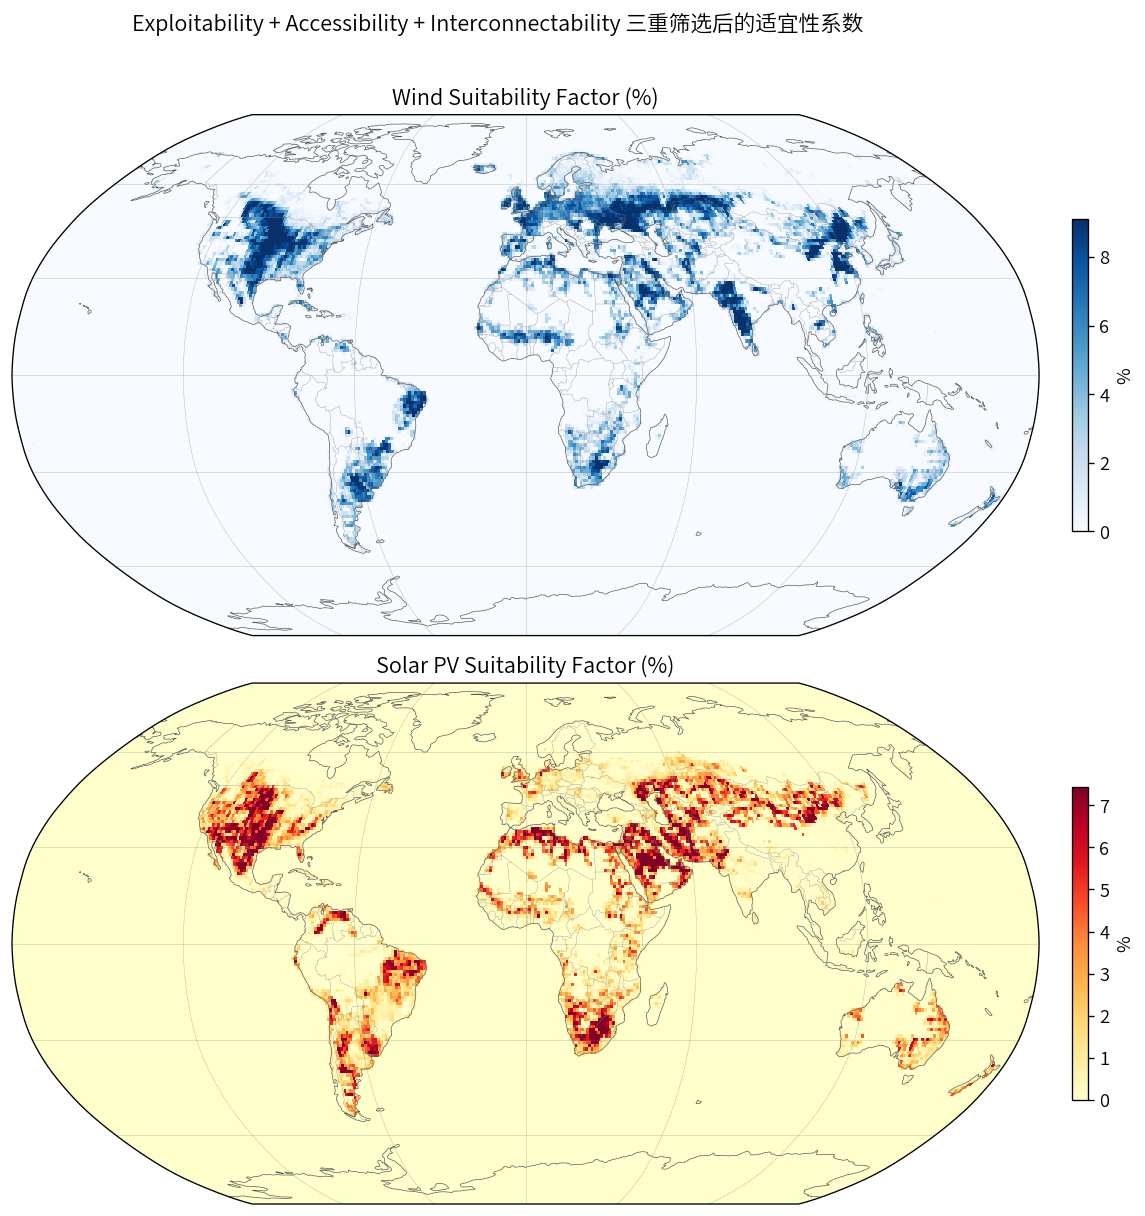

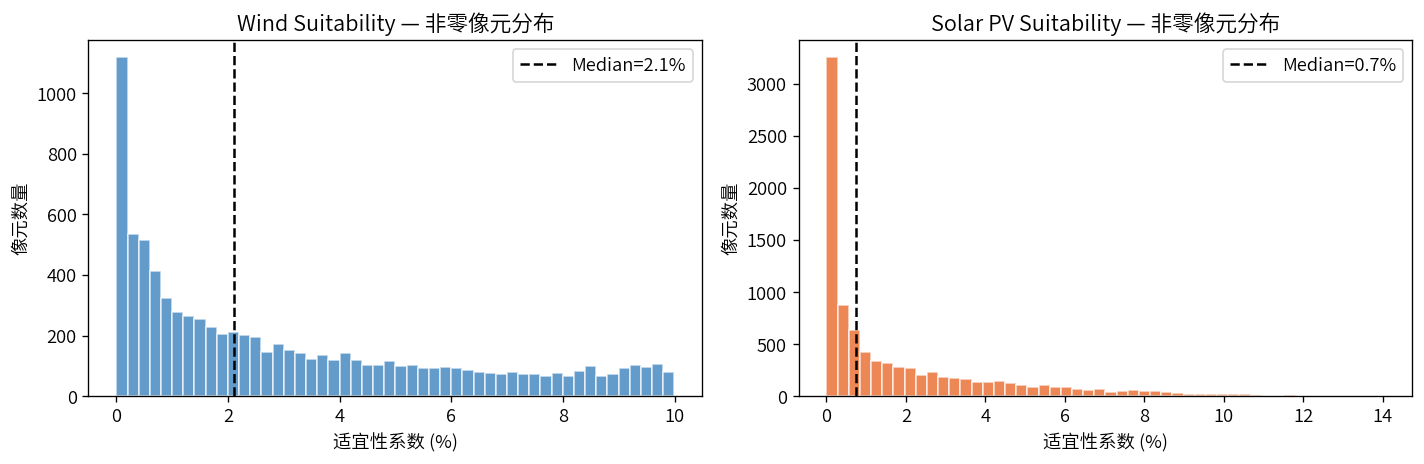

In [8]:
solar_net, slon, slat, solar_real = load_or_mock_tif(
    os.path.join(DATA_DIR, 'Global_Solar_Net_Area_Add_Egrid.tif'),
    mock_shape=(720, 1440), mock_range=(0, 15)  # 光伏最大适宜系数 15%
)

print_stats('Global_Solar_Net_Area_Add_Egrid (光伏适宜性 %)', solar_net, slon, slat)

fig, axes = plt.subplots(2, 1, figsize=(14, 10),
    subplot_kw={'projection': ccrs.Robinson()} if HAS_CARTOPY else {})

plot_global_map(axes[0], wind_net, wlon, wlat,
                title='Wind Suitability Factor (%)', cmap='Blues',
                cbar_label='%', is_mock=not wind_real)
plot_global_map(axes[1], solar_net, slon, slat,
                title='Solar PV Suitability Factor (%)', cmap='YlOrRd',
                cbar_label='%', is_mock=not solar_real)
plt.suptitle('Exploitability + Accessibility + Interconnectability 三重筛选后的适宜性系数',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# 直方图对比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, color, label in [
    (ax1, wind_net[wind_net>0],  '#2171b5', 'Wind'),
    (ax2, solar_net[solar_net>0], '#e6550d', 'Solar PV')
]:
    ax.hist(data.ravel(), bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f'{label} Suitability — 非零像元分布')
    ax.set_xlabel('适宜性系数 (%)')
    ax.set_ylabel('像元数量')
    ax.axvline(np.median(data), color='k', ls='--', lw=1.5, label=f'Median={np.median(data):.1f}%')
    ax.legend()
plt.tight_layout()
plt.show()

---
## Section 3 — 风电容量因子时间序列 (`Global_Wind_CFs_Sel.h5`)

**含义**：筛选后 8477 个风电候选格网 × 8760 小时的 CF 矩阵，由 ERA5 历史均值（2000–2022）计算


  Global_Wind_CFs_Sel.h5  [风电容量因子]
  Shape           : (8477, 8760)  (格网数 × 8760h)
  CF 范围         : [0.0026, 1.0000]
  全域均值 CF     : 0.2506
  年均 CF（每格网均值）
    最小: 0.0201  最大: 0.8259  均值: 0.2506


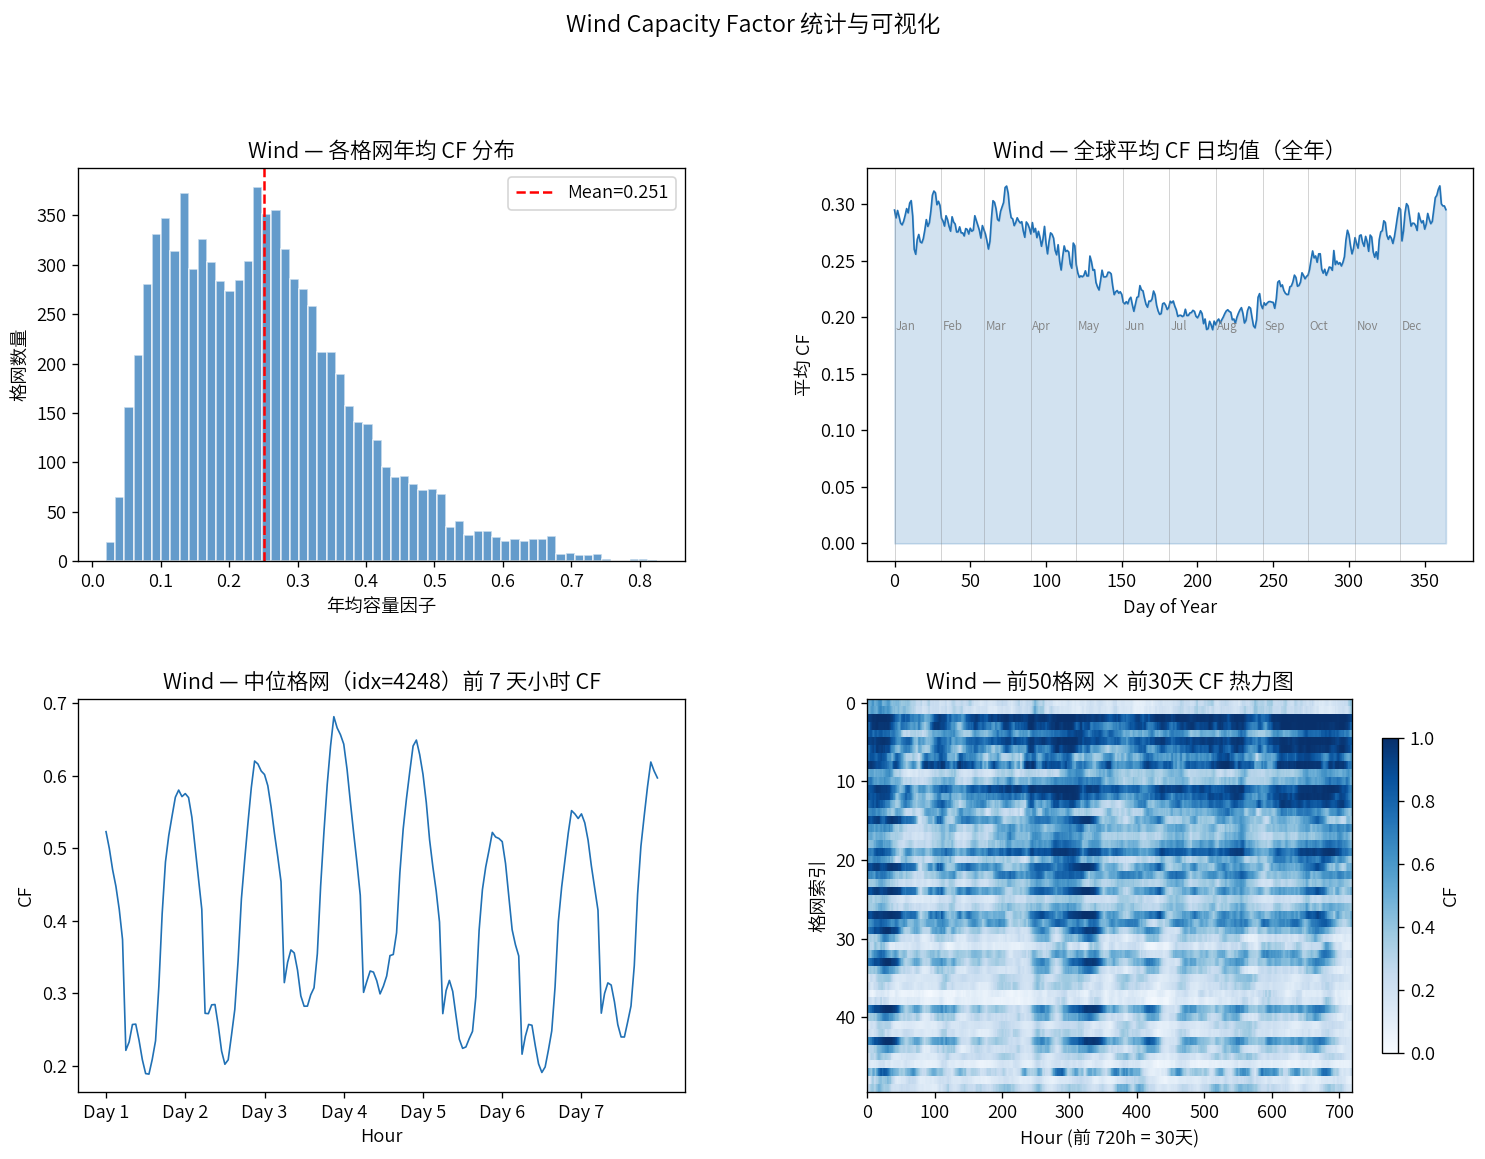

In [10]:
def load_or_mock_h5_cfs(filepath, dataset, mock_shape, mock_range=(0, 0.6)):
    if os.path.exists(filepath):
        with h5py.File(filepath, 'r') as f:
            data = f[dataset][:].astype(np.float32)
        # Ensure shape is (n_grids, n_hours) — transpose if needed
        if data.shape[0] == 8760 and data.shape[1] != 8760:
            data = data.T
        return data, True
    else:
        print(f'  [MOCK] {os.path.basename(filepath)} 未找到，使用模拟数据')
        np.random.seed(1)
        # 模拟带日周期和季节周期的 CF
        n_grids, n_hours = mock_shape
        hours = np.arange(n_hours)
        diurnal  = 0.15 * np.sin(2*np.pi*hours/24 - np.pi/4)
        seasonal = 0.10 * np.sin(2*np.pi*hours/8760 + np.pi)
        base = 0.30 + diurnal + seasonal
        noise = np.random.uniform(-0.05, 0.05, (n_grids, n_hours))
        data = np.clip(base[None,:] + noise, 0, 1).astype(np.float32)
        return data, False


wind_cfs, wind_cfs_real = load_or_mock_h5_cfs(
    os.path.join(DATA_DIR, 'Global_Wind_CFs_Sel.h5'), '/data',
    mock_shape=(8477, 8760)
)

print(f"\n{'='*55}")
print(f"  Global_Wind_CFs_Sel.h5  [风电容量因子]"
      + ('' if wind_cfs_real else ' [MOCK]'))
print(f"{'='*55}")
print(f"  Shape           : {wind_cfs.shape}  (格网数 × 8760h)")
print(f"  CF 范围         : [{wind_cfs.min():.4f}, {wind_cfs.max():.4f}]")
print(f"  全域均值 CF     : {wind_cfs.mean():.4f}")
print(f"  年均 CF（每格网均值）")
annual_cf_wind = wind_cfs.mean(axis=1)
print(f"    最小: {annual_cf_wind.min():.4f}  最大: {annual_cf_wind.max():.4f}  均值: {annual_cf_wind.mean():.4f}")

# 可视化
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# 1. 年均 CF 分布直方图
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(annual_cf_wind, bins=60, color='#2171b5', alpha=0.7, edgecolor='white')
ax1.axvline(annual_cf_wind.mean(), color='r', ls='--', lw=1.5,
            label=f'Mean={annual_cf_wind.mean():.3f}')
ax1.set_title('Wind — 各格网年均 CF 分布')
ax1.set_xlabel('年均容量因子')
ax1.set_ylabel('格网数量')
ax1.legend()

# 2. 全球日平均 CF 时间序列（365天）
ax2 = fig.add_subplot(gs[0, 1])
daily_mean = wind_cfs.mean(axis=0).reshape(365, 24).mean(axis=1)
ax2.plot(np.arange(365), daily_mean, color='#2171b5', lw=1)
ax2.fill_between(np.arange(365), daily_mean, alpha=0.2, color='#2171b5')
ax2.set_title('Wind — 全球平均 CF 日均值（全年）')
ax2.set_xlabel('Day of Year')
ax2.set_ylabel('平均 CF')
for m, label in zip([0,31,59,90,120,151,181,212,243,273,304,334],
                    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']):
    ax2.axvline(m, color='gray', alpha=0.4, lw=0.5)
    ax2.text(m+1, daily_mean.min(), label, fontsize=7, color='gray')

# 3. 典型格网（中位值格网）的小时 CF（前 7 天）
ax3 = fig.add_subplot(gs[1, 0])
med_idx = np.argsort(annual_cf_wind)[len(annual_cf_wind)//2]
ax3.plot(wind_cfs[med_idx, :168], color='#2171b5', lw=1)
ax3.set_title(f'Wind — 中位格网（idx={med_idx}）前 7 天小时 CF')
ax3.set_xlabel('Hour')
ax3.set_ylabel('CF')
ax3.set_xticks(np.arange(0, 168, 24))
ax3.set_xticklabels([f'Day {d+1}' for d in range(7)])

# 4. 热力图：前 50 个格网 × 前 30 天
ax4 = fig.add_subplot(gs[1, 1])
im = ax4.imshow(wind_cfs[:50, :720], aspect='auto', cmap='Blues',
                vmin=0, vmax=1, interpolation='nearest')
plt.colorbar(im, ax=ax4, shrink=0.8, label='CF')
ax4.set_title('Wind — 前50格网 × 前30天 CF 热力图')
ax4.set_xlabel('Hour (前 720h = 30天)')
ax4.set_ylabel('格网索引')

plt.suptitle('Wind Capacity Factor 统计与可视化' +
             ('' if wind_cfs_real else ' [MOCK DATA]'), fontsize=14, y=1.01)
plt.show()

---
## Section 4 — 光伏容量因子 (`Global_Solar_CFs.mat`)

**含义**：13296 个光伏候选格网 × 8760 小时的 CF，由 ERA5 辐照/气温代入 PVLIB 模型计算


  Global_Solar_CFs.mat  [光伏容量因子]
  Shape           : (13296, 8760)  (格网数 × 8760h)
  CF 范围         : [0.0000, 0.9000]
  全域均值 CF     : 0.1678
  年均 CF 最小: 0.0516  最大: 0.2401  均值: 0.1678


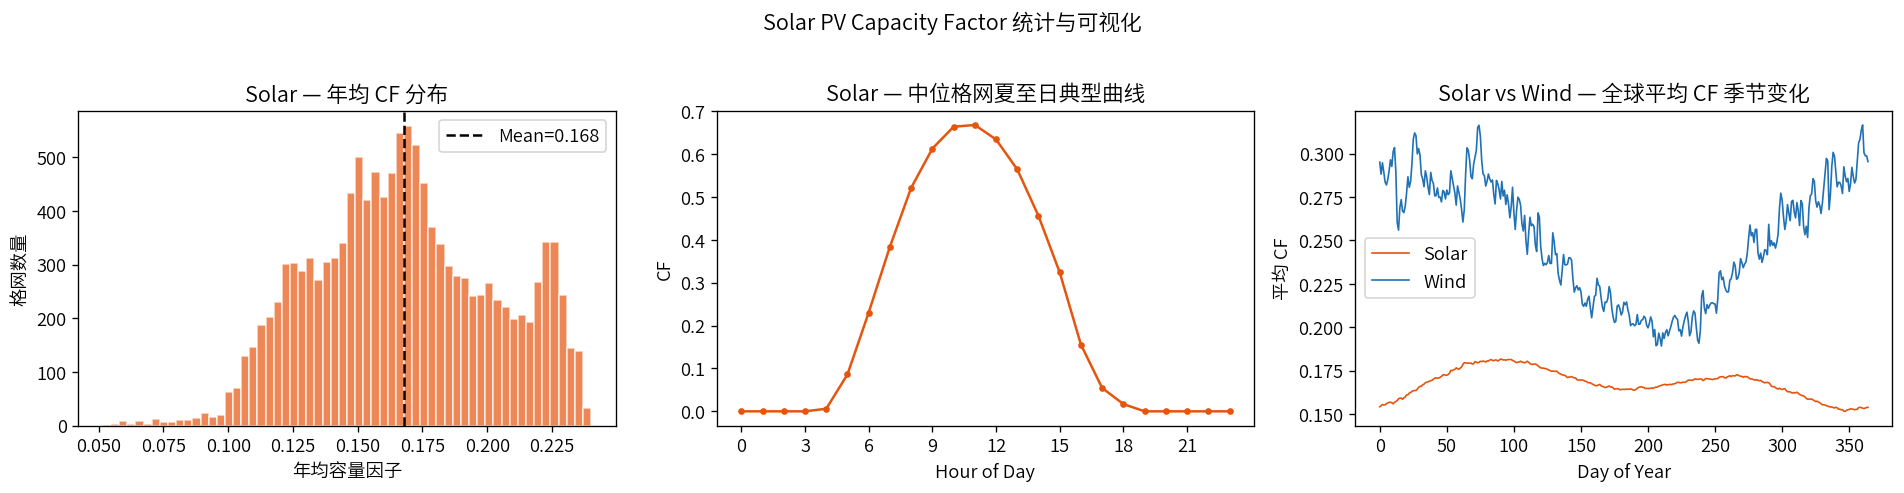

In [11]:
def load_or_mock_mat_cfs(filepath, varname, mock_shape, mock_range=(0, 0.25)):
    if os.path.exists(filepath):
        try:
            mat = scipy.io.loadmat(filepath)
            data = mat[varname].astype(np.float32)
            # MATLAB 代码: res_CF = res_CF/10/1000 → 还原原始 CF
            data = data / 10 / 1000
            return data, True
        except Exception as e:
            print(f'  [WARN] 读取 .mat 失败: {e}')
    print(f'  [MOCK] {os.path.basename(filepath)} 未找到，使用模拟数据')
    np.random.seed(2)
    n_grids, n_hours = mock_shape
    hours = np.arange(n_hours)
    # 光伏白天有值、夜间为 0
    hour_of_day = hours % 24
    solar_bell = np.where(
        (hour_of_day >= 6) & (hour_of_day <= 18),
        0.4 * np.sin(np.pi * (hour_of_day - 6) / 12),
        0.0
    )
    seasonal = 0.05 * np.sin(2*np.pi*hours/8760)
    base = solar_bell + seasonal
    noise = np.random.uniform(-0.02, 0.02, (n_grids, n_hours))
    data = np.clip(base[None,:] + noise, 0, 1).astype(np.float32)
    return data, False


solar_cfs, solar_cfs_real = load_or_mock_mat_cfs(
    os.path.join(DATA_DIR, 'Global_Solar_CFs.mat'), 'res_CF',
    mock_shape=(13296, 8760)
)

print(f"\n{'='*55}")
print(f"  Global_Solar_CFs.mat  [光伏容量因子]"
      + ('' if solar_cfs_real else ' [MOCK]'))
print(f"{'='*55}")
print(f"  Shape           : {solar_cfs.shape}  (格网数 × 8760h)")
print(f"  CF 范围         : [{solar_cfs.min():.4f}, {solar_cfs.max():.4f}]")
print(f"  全域均值 CF     : {solar_cfs.mean():.4f}")
annual_cf_solar = solar_cfs.mean(axis=1)
print(f"  年均 CF 最小: {annual_cf_solar.min():.4f}  最大: {annual_cf_solar.max():.4f}  均值: {annual_cf_solar.mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 年均 CF 直方图
axes[0].hist(annual_cf_solar, bins=60, color='#e6550d', alpha=0.7, edgecolor='white')
axes[0].axvline(annual_cf_solar.mean(), color='k', ls='--', lw=1.5,
                label=f'Mean={annual_cf_solar.mean():.3f}')
axes[0].set_title('Solar — 年均 CF 分布')
axes[0].set_xlabel('年均容量因子')
axes[0].set_ylabel('格网数量')
axes[0].legend()

# 典型日（夏至附近，第172天）的 24h 曲线
day172_start = 172 * 24
med_s_idx = np.argsort(annual_cf_solar)[len(annual_cf_solar)//2]
axes[1].plot(solar_cfs[med_s_idx, day172_start:day172_start+24],
             color='#e6550d', lw=1.5, marker='o', ms=3)
axes[1].set_title('Solar — 中位格网夏至日典型曲线')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('CF')
axes[1].set_xticks(range(0, 24, 3))

# 风光 CF 对比：全年日均曲线
daily_solar = solar_cfs.mean(axis=0).reshape(365, 24).mean(axis=1)
daily_wind2 = wind_cfs.mean(axis=0).reshape(365, 24).mean(axis=1)
axes[2].plot(daily_solar, color='#e6550d', lw=1, label='Solar')
axes[2].plot(daily_wind2,  color='#2171b5', lw=1, label='Wind')
axes[2].set_title('Solar vs Wind — 全球平均 CF 季节变化')
axes[2].set_xlabel('Day of Year')
axes[2].set_ylabel('平均 CF')
axes[2].legend()

plt.suptitle('Solar PV Capacity Factor 统计与可视化' +
             ('' if solar_cfs_real else ' [MOCK DATA]'), y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 5 — 电力负荷数据 (`Global_Load_22region.mat`)

**含义**：20 个区域 × 8760 小时的逐时电力需求（SSP1-2.6 情景下，IIASA GDP/人口驱动 + 正弦函数叠加模型预测的 2050s 负荷），全球总量归一化至 IEA NZE 情景的 71,164 TWh/年


  Global_Load_22region.mat  [区域电力需求]
  Shape           : (20, 8760)  (20 区域 × 8760h)
  全球峰值负荷    : 13.591 TW
  全球年总需求    : 97238.1 TWh/年 → 97238.1 TW·h

  各区域年均负荷 (TW):
     1. Northern America    : 0.8989 TW  (年均: 7874.6 TWh)
     2. Caribbean           : 0.2438 TW  (年均: 2135.3 TWh)
     3. Central America     : 0.1124 TW  (年均: 984.9 TWh)
     4. Southern America    : 0.7242 TW  (年均: 6344.0 TWh)
     5. Northern Europe     : 0.2135 TW  (年均: 1870.6 TWh)
     6. Western Europe      : 0.3108 TW  (年均: 2722.3 TWh)
     7. Southern Europe     : 0.1605 TW  (年均: 1406.2 TWh)
     8. Eastern Europe      : 0.3401 TW  (年均: 2979.3 TWh)
     9. Central Asia        : 0.1124 TW  (年均: 984.8 TWh)
    10. Eastern Asia        : 2.1410 TW  (年均: 18755.5 TWh)
    11. Southern Asia       : 0.4588 TW  (年均: 4019.2 TWh)
    12. Southeastern Asia   : 2.3421 TW  (年均: 20517.1 TWh)
    13. Western Asia        : 0.7980 TW  (年均: 6990.5 TWh)
    14. Australia-NZ        : 0.0134 TW  (年均: 117.6 TWh)
    15. Melanesia  

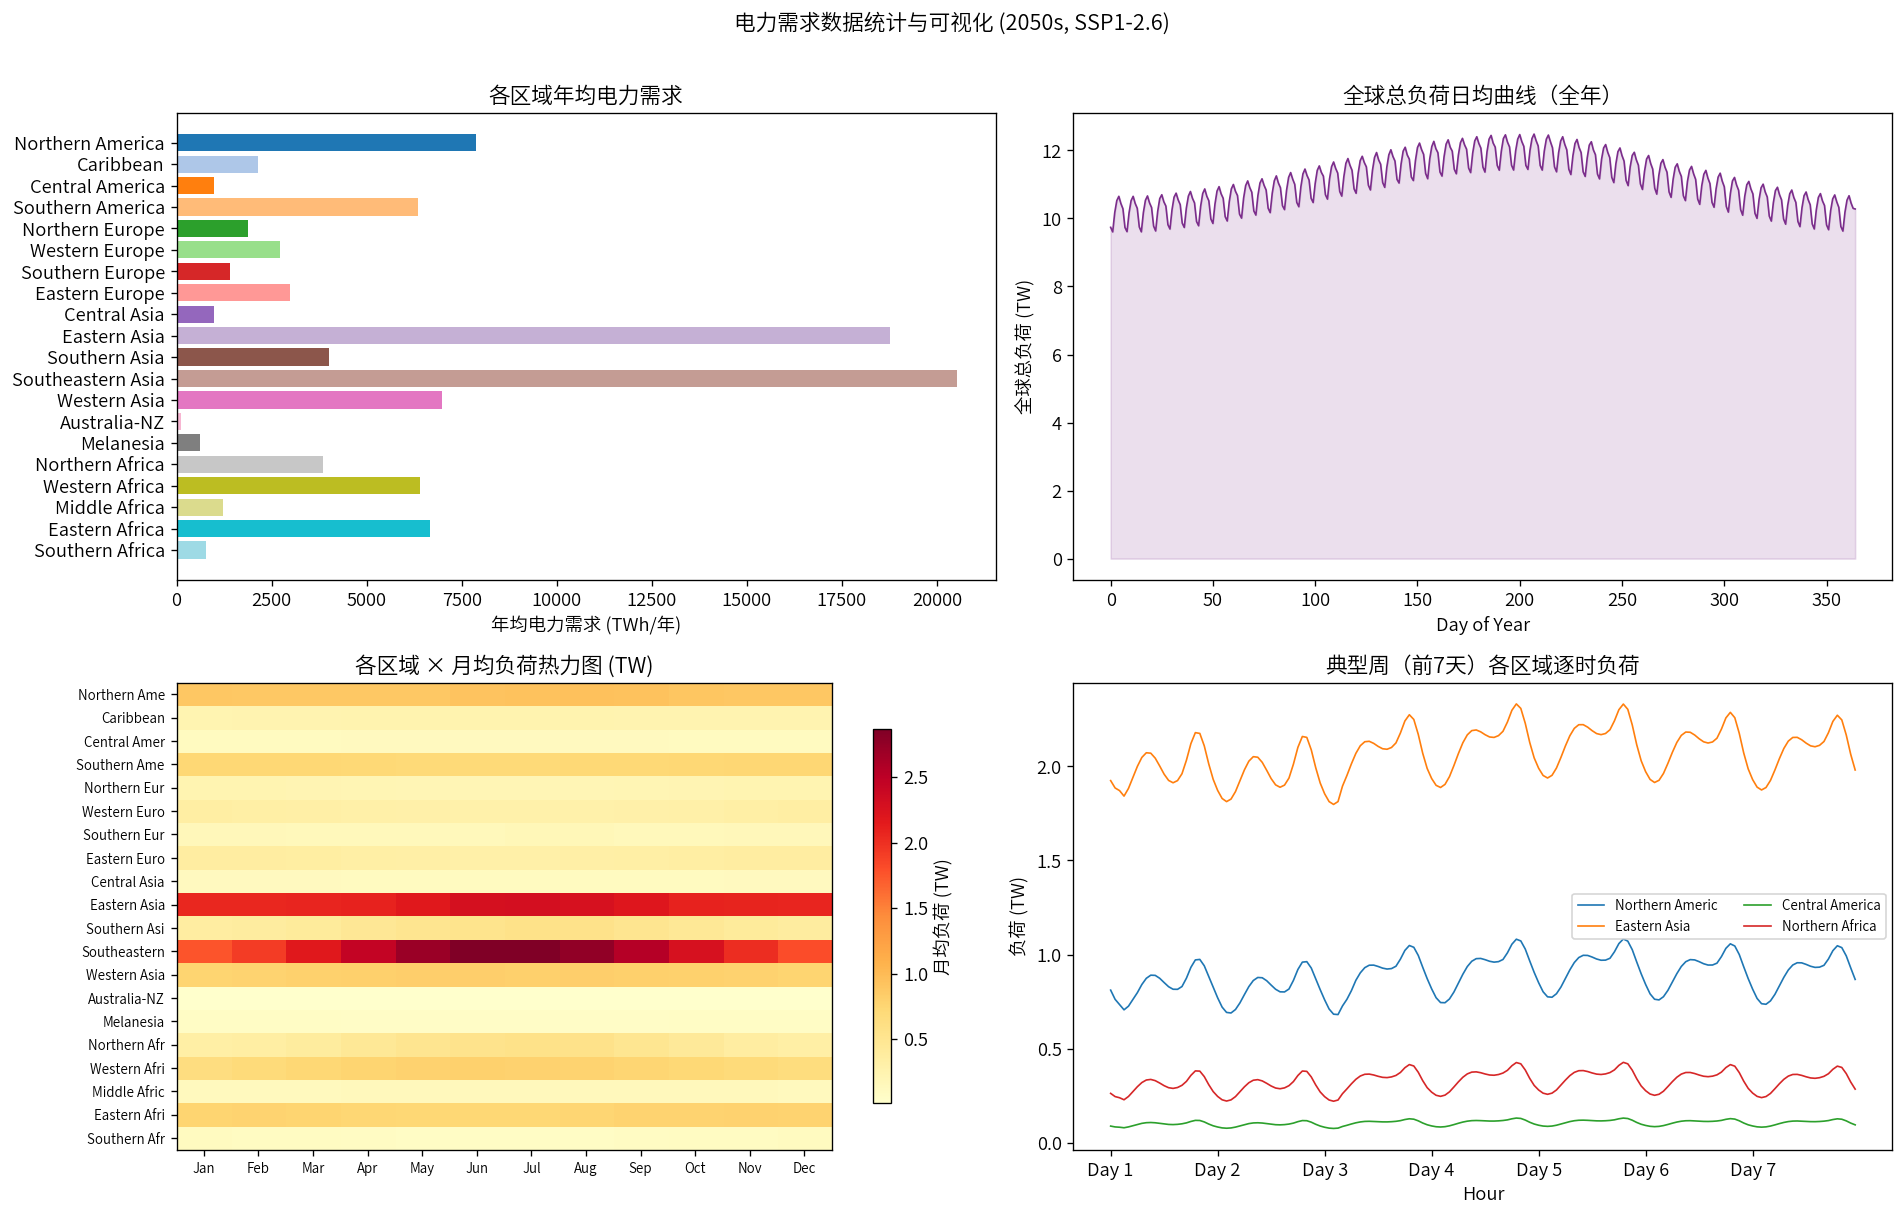

In [12]:
def load_or_mock_loads(filepath, varname='all_loads', mock_n_regions=20):
    if os.path.exists(filepath):
        try:
            mat = scipy.io.loadmat(filepath)
            data = mat[varname]  # shape: (phases, regions, 8760) or similar
            # 取第4个切片 (index 3) = 2050s，与 MATLAB 代码一致
            if data.ndim == 3:
                loads = data[3, :, :].astype(np.float64) / 1e6  # GW → TW
            else:
                loads = data.astype(np.float64) / 1e6
            return loads, True
        except Exception as e:
            print(f'  [WARN] {e}')
    print(f'  [MOCK] {os.path.basename(filepath)} 未找到，使用模拟数据')
    np.random.seed(3)
    hours = np.arange(8760)
    # 各区域基准负荷（参考论文图 S15 量级，单位 TW）
    base_loads = np.array([
        0.8, 0.05, 0.05, 0.25,  # Americas
        0.12, 0.18, 0.12, 0.10, # Europe
        0.08, 0.95, 0.35, 0.22, # Asia
        0.15, 0.06, 0.02,        # W.Asia, Oceania, Melanesia
        0.06, 0.06, 0.04, 0.04, 0.05  # Africa
    ])
    diurnal  = 0.15 * np.sin(2*np.pi*hours/24 - np.pi/3)
    seasonal = 0.08 * np.sin(2*np.pi*hours/8760 + np.pi)
    shape = 1 + diurnal + seasonal
    loads = base_loads[:, None] * shape[None, :]
    loads += np.random.uniform(-0.01, 0.01, loads.shape)
    loads = np.clip(loads, 0, None)
    # 归一化至 71164 TWh/年（IEA NZE 2050）
    total_now = loads.sum()
    loads = loads / total_now * (71164 / 8760)  # 使全年总量 = 71164 TWh
    return loads, False


loads, loads_real = load_or_mock_loads(
    os.path.join(DATA_DIR, 'Global_Load_22region.mat')
)

print(f"\n{'='*55}")
print(f"  Global_Load_22region.mat  [区域电力需求]"
      + ('' if loads_real else ' [MOCK]'))
print(f"{'='*55}")
print(f"  Shape           : {loads.shape}  (20 区域 × 8760h)")
print(f"  全球峰值负荷    : {loads.sum(axis=0).max():.3f} TW")
print(f"  全球年总需求    : {loads.sum()*8760/8760:.1f} TWh/年 → {loads.sum():.1f} TW·h")
print(f"\n  各区域年均负荷 (TW):")
for i, (name, val) in enumerate(zip(REGION_NAMES, loads.mean(axis=1))):
    print(f"    {i+1:2d}. {name:<20s}: {val:.4f} TW  "
          f"(年均: {val*8760:.1f} TWh)")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 各区域年均负荷条形图
ax = axes[0, 0]
colors = plt.cm.tab20(np.linspace(0, 1, 20))
bars = ax.barh(REGION_NAMES, loads.mean(axis=1)*8760, color=colors)
ax.set_xlabel('年均电力需求 (TWh/年)')
ax.set_title('各区域年均电力需求')
ax.invert_yaxis()

# 2. 全球总负荷：日均时间序列（全年）
ax = axes[0, 1]
global_load = loads.sum(axis=0)
daily_gl = global_load.reshape(365, 24).mean(axis=1)
ax.plot(daily_gl, color='#7b2d8b', lw=1)
ax.fill_between(range(365), daily_gl, alpha=0.15, color='#7b2d8b')
ax.set_title('全球总负荷日均曲线（全年）')
ax.set_xlabel('Day of Year')
ax.set_ylabel('全球总负荷 (TW)')

# 3. 各区域 × 月均负荷热力图
ax = axes[1, 0]
monthly_loads = []
days_in_month = [31,28,31,30,31,30,31,31,30,31,30,31]
start = 0
for dm in days_in_month:
    end = start + dm * 24
    monthly_loads.append(loads[:, start:end].mean(axis=1))
    start = end
monthly_loads = np.array(monthly_loads).T  # (20, 12)
im = ax.imshow(monthly_loads, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax, shrink=0.8, label='月均负荷 (TW)')
ax.set_yticks(range(20))
ax.set_yticklabels([n[:12] for n in REGION_NAMES], fontsize=8)
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=8)
ax.set_title('各区域 × 月均负荷热力图 (TW)')

# 4. 典型周的区域负荷曲线（前 7 天，选 4 个大区）
ax = axes[1, 1]
highlight = [0, 9, 2, 15]  # N.America, E.Asia, C.America, N.Africa
for idx in highlight:
    ax.plot(loads[idx, :168], lw=1, label=REGION_NAMES[idx][:15])
ax.set_title('典型周（前7天）各区域逐时负荷')
ax.set_xlabel('Hour')
ax.set_ylabel('负荷 (TW)')
ax.set_xticks(np.arange(0, 168, 24))
ax.set_xticklabels([f'Day {d+1}' for d in range(7)])
ax.legend(fontsize=8, ncol=2)

plt.suptitle('电力需求数据统计与可视化 (2050s, SSP1-2.6)' +
             ('' if loads_real else ' [MOCK DATA]'), fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Section 6 — 系统初始状态与互联结构 (`Global_Init_State.mat` & `Global_Trans.mat`)

**含义**：现有装机（`cur_solar`, `cur_wind`, `cur_storage`）作为非线性约束下界；互联拓扑矩阵（S-G 全球互联）和输电损耗矩阵


  Global_Init_State  [现有装机/互联状态]
  cur_solar shape  : (20,)
  cur_wind  shape  : (20,)
  cur_trans shape  : (20, 20)

  各区域现有装机 (GW):
  区域                         Solar      Wind   Storage
  --------------------------------------------------
  Northern America        143609.0  164968.0   19107.6
  Caribbean                12825.0    8644.0       6.0
  Central America          13406.0   10857.0       0.0
  Southern America         49076.0   39785.0     974.0
  Northern Europe          27172.0   54849.0    3652.0
  Western Europe          147453.0   76528.0   10329.7
  Southern Europe          71890.0   44928.8    8584.0
  Eastern Europe           40239.0   18449.0    7661.0
  Central Asia              1555.5    1440.8       0.0
  Eastern Asia            734202.0  288772.4   80139.1
  Southern Asia            29577.0   13440.0     540.0
  Southeastern Asia        74017.0   47215.0    5825.6
  Western Asia             25748.0    6902.0    1296.0
  Australia-NZ               324.4      72

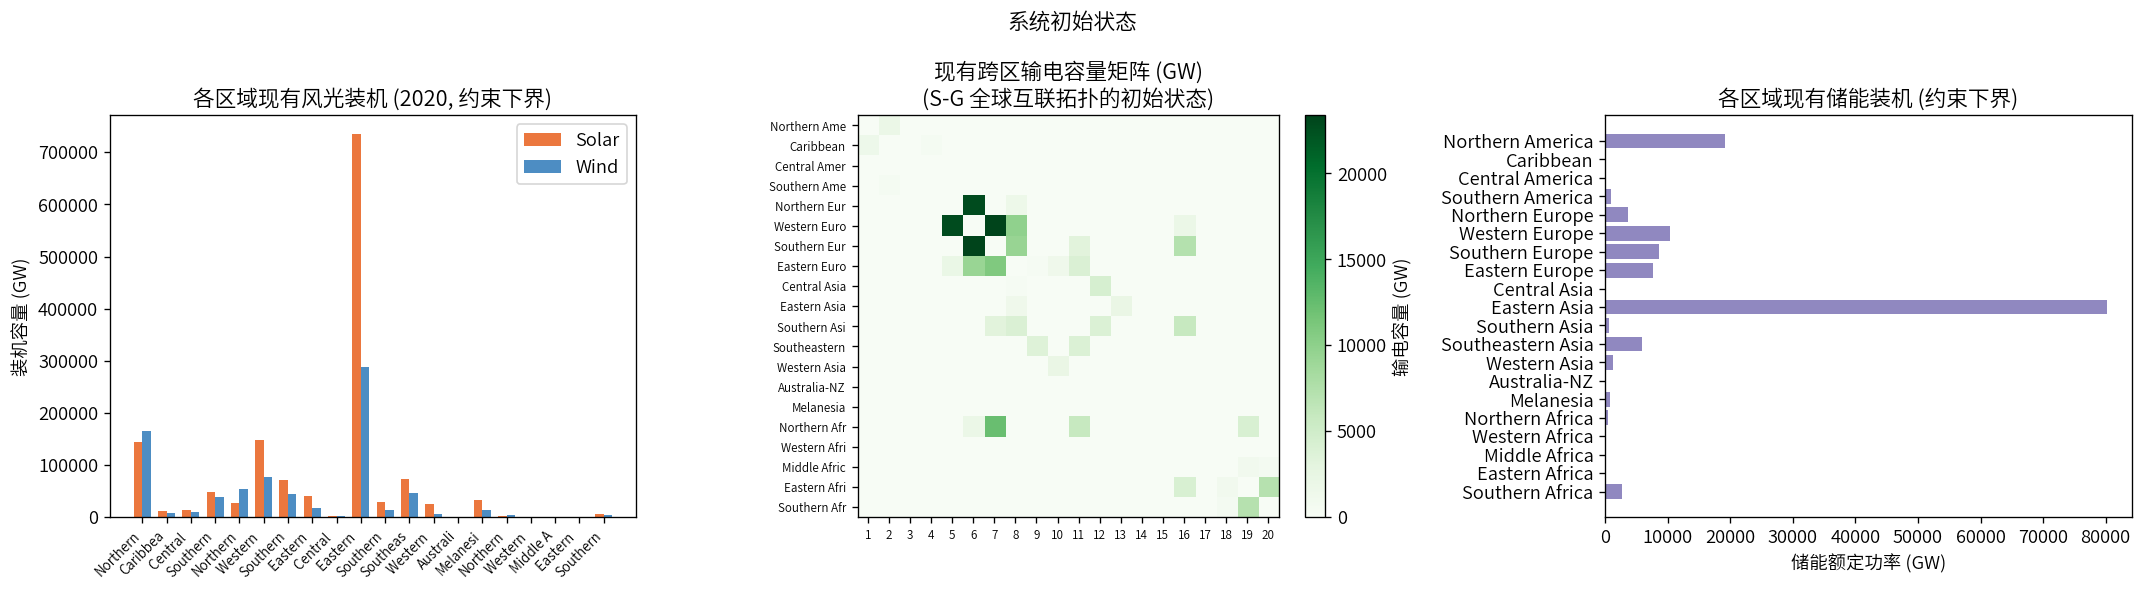

In [13]:
def load_or_mock_init_state(filepath):
    if os.path.exists(filepath):
        mat = scipy.io.loadmat(filepath)
        cur_solar   = mat['cur_solar'].ravel().astype(np.float64)
        cur_wind    = mat['cur_wind'].ravel().astype(np.float64)
        cur_storage = mat['cur_storage'].ravel().astype(np.float64)
        cur_trans   = mat['cur_trans'].astype(np.float64)
        return cur_solar, cur_wind, cur_storage, cur_trans, True
    print('  [MOCK] Global_Init_State.mat 未找到，使用模拟数据')
    # 参考 IRENA 2024 各区域现有装机（GW，简化估计）
    cur_solar   = np.array([200,2,5,50, 30,200,100,20, 10,600,50,20, 30,30,1, 10,2,2,2,5], dtype=np.float64)
    cur_wind    = np.array([150,1,3,30, 30,100,30,15,  5,400,20,5,  20,20,1,  5,1,1,1,3], dtype=np.float64)
    cur_storage = np.array([20,1,1,5,  5,15,8,3,  2,50,5,3,  5,5,0.5, 1,0.5,0.5,0.5,1], dtype=np.float64)
    cur_trans   = np.zeros((20, 20))
    # 欧洲内部互联
    for i,j in [(4,5),(4,6),(5,6),(5,7),(6,7)]: cur_trans[i,j]=cur_trans[j,i]=50
    # 亚洲内部
    for i,j in [(8,9),(9,10),(9,11),(10,11)]: cur_trans[i,j]=cur_trans[j,i]=30
    return cur_solar, cur_wind, cur_storage, cur_trans, False


cur_solar, cur_wind, cur_storage, cur_trans, init_real = load_or_mock_init_state(
    os.path.join(DATA_DIR, 'Global_Init_State.mat')
)

print(f"\n{'='*55}")
print(f"  Global_Init_State  [现有装机/互联状态]"
      + ('' if init_real else ' [MOCK]'))
print(f"{'='*55}")
print(f"  cur_solar shape  : {cur_solar.shape}")
print(f"  cur_wind  shape  : {cur_wind.shape}")
print(f"  cur_trans shape  : {cur_trans.shape}")
print(f"\n  各区域现有装机 (GW):")
header = f"  {'区域':<22}  {'Solar':>8}  {'Wind':>8}  {'Storage':>8}"
print(header)
print('  ' + '-'*50)
for i, name in enumerate(REGION_NAMES):
    print(f"  {name:<22}  {cur_solar[i]:8.1f}  {cur_wind[i]:8.1f}  {cur_storage[i]:8.1f}")
print(f"\n  全球合计: Solar={cur_solar.sum():.0f} GW, Wind={cur_wind.sum():.0f} GW")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. 各区域现有装机条形图
x = np.arange(20)
width = 0.35
axes[0].bar(x - width/2, cur_solar, width, label='Solar', color='#e6550d', alpha=0.8)
axes[0].bar(x + width/2, cur_wind,  width, label='Wind',  color='#2171b5', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([n[:8] for n in REGION_NAMES], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('装机容量 (GW)')
axes[0].set_title('各区域现有风光装机 (2020, 约束下界)')
axes[0].legend()

# 2. 现有跨区输电容量矩阵（热力图）
im2 = axes[1].imshow(cur_trans, cmap='Greens', aspect='auto')
plt.colorbar(im2, ax=axes[1], label='输电容量 (GW)')
axes[1].set_xticks(range(20))
axes[1].set_yticks(range(20))
axes[1].set_xticklabels([str(i+1) for i in range(20)], fontsize=7)
axes[1].set_yticklabels([n[:12] for n in REGION_NAMES], fontsize=7)
axes[1].set_title('现有跨区输电容量矩阵 (GW)\n(S-G 全球互联拓扑的初始状态)')

# 3. 现有储能容量
axes[2].barh(REGION_NAMES, cur_storage, color='#756bb1', alpha=0.8)
axes[2].set_xlabel('储能额定功率 (GW)')
axes[2].set_title('各区域现有储能装机 (约束下界)')
axes[2].invert_yaxis()

plt.suptitle('系统初始状态' + ('' if init_real else ' [MOCK DATA]'), fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 7 — 提取最优解 & 可视化场站位置

### 7.1 读取优化结果并分析帕累托前沿


  优化结果
  res_scale shape    : (12783, 70)  (帕累托解数 × 决策变量数)
  prs shape          : (70, 3)  (帕累托解数 × 3目标)

  帕累托前沿统计:
  f(1) 弃电率       : [0.0461, 0.2365]  均值=0.0865
  f(2) 1-渗透率     : [0.1051, 0.2380]  均值=0.1392
  f(3) 投资成本     : [86072.5, 167550.3] 万亿USD  均值=119853.3


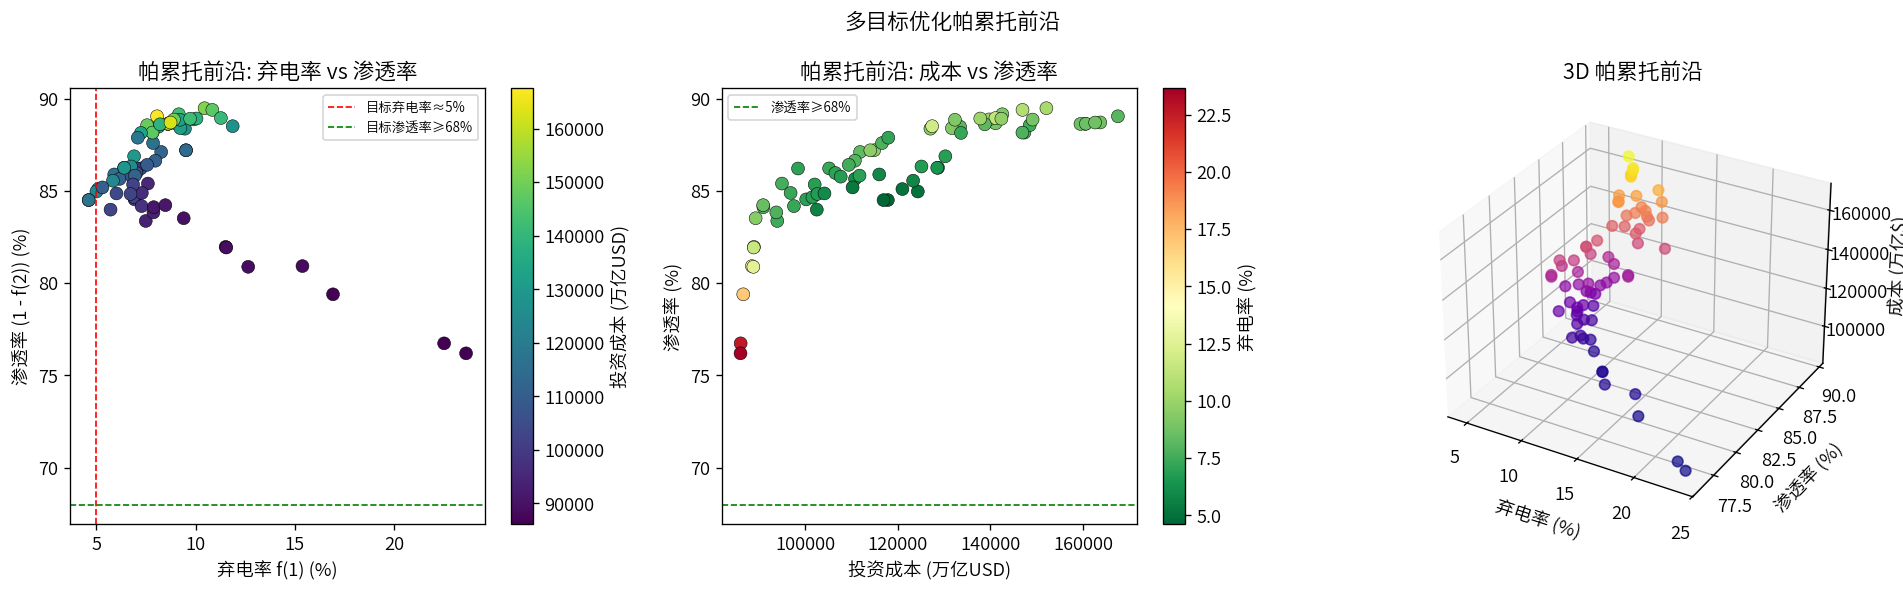

In [16]:
def load_or_mock_results(result_file):
    if os.path.exists(result_file):
        with h5py.File(result_file, "r") as f:
            res_scale = f["/res_scale"][:]
            prs = f["/prs"][:]
        # MATLAB 保存的 HDF5 矩阵是列优先，Python 读出来行列互换
        # 确保 shape 为 (n_pareto, n_vars) 和 (n_pareto, 3)
        if res_scale.ndim == 2 and res_scale.shape[0] < res_scale.shape[1]:
            res_scale = res_scale.T  # (70, 12783) → (12783, 70)
        if prs.ndim == 2 and prs.shape[0] == 3:
            prs = prs.T  # (3, 70) → (70, 3)
        return res_scale, prs, True
    raise FileNotFoundError(f"结果文件 {result_file} 未找到，无法加载优化结果")


res_scale, prs, res_real = load_or_mock_results(RESULT_FILE)

print(f"\n{'='*55}")
print(f"  优化结果" + ("" if res_real else " [MOCK]"))
print(f"{'='*55}")
print(f"  res_scale shape    : {res_scale.shape}  (帕累托解数 × 决策变量数)")
print(f"  prs shape          : {prs.shape}  (帕累托解数 × 3目标)")
print(f"\n  帕累托前沿统计:")
print(f"  f(1) 弃电率       : [{prs[:,0].min():.4f}, {prs[:,0].max():.4f}]  均值={prs[:,0].mean():.4f}")
print(f"  f(2) 1-渗透率     : [{prs[:,1].min():.4f}, {prs[:,1].max():.4f}]  均值={prs[:,1].mean():.4f}")
print(f"  f(3) 投资成本     : [{prs[:,2].min():.1f}, {prs[:,2].max():.1f}] 万亿USD  均值={prs[:,2].mean():.1f}")

# 可视化帕累托前沿
fig = plt.figure(figsize=(16, 5))

# 2D: curtailment vs penetration
ax1 = fig.add_subplot(131)
sc1 = ax1.scatter(prs[:, 0] * 100, (1 - prs[:, 1]) * 100, c=prs[:, 2], cmap="viridis", s=60, edgecolors="k", lw=0.3)
plt.colorbar(sc1, ax=ax1, label="投资成本 (万亿USD)")
ax1.set_xlabel("弃电率 f(1) (%)")
ax1.set_ylabel("渗透率 (1 - f(2)) (%)")
ax1.set_title("帕累托前沿: 弃电率 vs 渗透率")
ax1.axvline(5, color="r", ls="--", lw=1, label="目标弃电率≈5%")
ax1.axhline(68, color="g", ls="--", lw=1, label="目标渗透率≥68%")
ax1.legend(fontsize=8)

# 2D: cost vs penetration
ax2 = fig.add_subplot(132)
sc2 = ax2.scatter(prs[:, 2], (1 - prs[:, 1]) * 100, c=prs[:, 0] * 100, cmap="RdYlGn_r", s=60, edgecolors="k", lw=0.3)
plt.colorbar(sc2, ax=ax2, label="弃电率 (%)")
ax2.set_xlabel("投资成本 (万亿USD)")
ax2.set_ylabel("渗透率 (%)")
ax2.set_title("帕累托前沿: 成本 vs 渗透率")
ax2.axhline(68, color="g", ls="--", lw=1, label="渗透率≥68%")
ax2.legend(fontsize=8)

# 3D 帕累托前沿
ax3 = fig.add_subplot(133, projection="3d")
sc3 = ax3.scatter(prs[:, 0] * 100, (1 - prs[:, 1]) * 100, prs[:, 2], c=prs[:, 2], cmap="plasma", s=40, alpha=0.7)
ax3.set_xlabel("弃电率 (%)", labelpad=6)
ax3.set_ylabel("渗透率 (%)", labelpad=6)
ax3.set_zlabel("成本 (万亿$)", labelpad=6)
ax3.set_title("3D 帕累托前沿")

plt.suptitle("多目标优化帕累托前沿" + ("" if res_real else " [MOCK DATA]"), fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
with h5py.File(RESULT_FILE, 'r') as f:
    print("文件中所有 key：", list(f.keys()))
    for k in f.keys():
        print(f"  {k}: shape={f[k].shape}, dtype={f[k].dtype}")

文件中所有 key： ['prs', 'res_scale']
  prs: shape=(3, 70), dtype=float64
  res_scale: shape=(12783, 70), dtype=float64


### 7.2 按论文标准筛选最优解

**筛选条件**（来自论文方法）：渗透率 ≥ 68%（即 f(2) ≤ 0.32），弃电率 ≈ 5%（f(1) ≤ 0.06），在满足条件的解中取**投资成本最小**者

In [ ]:
# ── 筛选条件 ──────────────────────────────────────
PENETRATION_MIN  = 0.68   # 渗透率下限
CURTAILMENT_MAX  = 0.06   # 弃电率上限（~5%，略放宽到6%）
# ──────────────────────────────────────────────────

cr_ok   = prs[:, 0] <= CURTAILMENT_MAX
pen_ok  = prs[:, 1] <= (1 - PENETRATION_MIN)
feasible_mask = cr_ok & pen_ok
feasible_idx  = np.where(feasible_mask)[0]

print(f"满足渗透率≥{PENETRATION_MIN*100:.0f}% 且 弃电率≤{CURTAILMENT_MAX*100:.0f}% 的解数量: {len(feasible_idx)}")

if len(feasible_idx) == 0:
    print("\n  ★ 未找到满足双重约束的解，放宽条件（仅要求渗透率≥68%）")
    feasible_idx = np.where(prs[:, 1] <= (1 - PENETRATION_MIN))[0]
    print(f"  放宽后满足的解数量: {len(feasible_idx)}")

# 在可行解中，选投资成本最小的
best_local = np.argmin(prs[feasible_idx, 2])
best_idx   = feasible_idx[best_local]

best_cr   = prs[best_idx, 0]
best_pen  = 1 - prs[best_idx, 1]
best_cost = prs[best_idx, 2]
best_sol  = res_scale[best_idx, :]

print(f"\n{'='*55}")
print(f"  最优解 (第 {best_idx} 个帕累托解)")
print(f"{'='*55}")
print(f"  弃电率          : {best_cr*100:.2f}%")
print(f"  渗透率          : {best_pen*100:.2f}%")
print(f"  总投资          : {best_cost:.1f} 万亿 USD")

# 从决策变量中解析场站、储能、输电
n_solar_cand = 13296  # 与代码中 solar_index 长度对应
n_wind_cand  = 8477
n_cand_total = n_solar_cand + n_wind_cand

selection = np.round(best_sol[:n_cand_total]).astype(int)
solar_sel = selection[:n_solar_cand]
wind_sel  = selection[n_solar_cand:]

storage_pow = best_sol[n_cand_total:n_cand_total+20]
storage_dur = best_sol[n_cand_total+20:n_cand_total+40]
trans_cap   = best_sol[n_cand_total+40:]

print(f"\n  选中光伏格网数  : {solar_sel.sum():,} / {n_solar_cand:,} "
      f"({solar_sel.mean()*100:.1f}%)")
print(f"  选中风电格网数  : {wind_sel.sum():,} / {n_wind_cand:,} "
      f"({wind_sel.mean()*100:.1f}%)")
print(f"\n  各区域储能功率 (GW):")
for i, (name, sp, sd) in enumerate(zip(REGION_NAMES, storage_pow, storage_dur)):
    cap_gwh = sp * sd
    print(f"    {name:<22}: {sp:.0f} GW × {sd:.0f}h = {cap_gwh:.0f} GWh")
print(f"\n  输电走廊容量 (GW): 均值={trans_cap.mean():.0f}  最大={trans_cap.max():.0f}")

满足渗透率≥68% 且 弃电率≤6% 的解数量: 8

  最优解 (第 0 个帕累托解)
  弃电率          : 5.71%
  渗透率          : 83.99%
  总投资          : 102541.8 万亿 USD

  选中光伏格网数  : 27 / 13,296 (38.6%)
  选中风电格网数  : 0 / 8,477 (nan%)

  各区域储能功率 (GW):


ValueError: zero-size array to reduction operation maximum which has no identity

### 7.3 可视化最优解场站位置

In [ ]:
def get_grid_lonlat(grid_tif, selected_linear_idx, mock_shape=(720, 1440)):
    """将线性像元索引转换为经纬度坐标"""
    if HAS_RASTERIO and os.path.exists(grid_tif):
        with rasterio.open(grid_tif) as src:
            nrows, ncols = src.shape
            transform = src.transform
        rows, cols = np.unravel_index(selected_linear_idx, (nrows, ncols))
        # 像元中心坐标
        lons = transform.c + (cols + 0.5) * transform.a
        lats = transform.f + (rows + 0.5) * transform.e
        return lons, lats
    else:
        # 模拟：假设全球均匀格网
        nrows, ncols = mock_shape
        rows, cols = np.unravel_index(selected_linear_idx, (nrows, ncols))
        lons = -180 + (cols + 0.5) * 360 / ncols
        lats =   90 - (rows + 0.5) * 180 / nrows
        return lons, lats


# 注：实际使用时，solar_index / win_index 应从重跑数据准备段获取
# 此处用模拟格网做演示：均匀分布在全球有效区域
np.random.seed(42)

# 模拟候选格网的全局线性索引（仿照代码中 solar_index / win_index）
all_pixel_count = 720 * 1440
mock_solar_idx = np.random.choice(all_pixel_count, 13296, replace=False)
mock_wind_idx  = np.random.choice(all_pixel_count, 8477,  replace=False)

# 获取被选中的格网坐标
solar_chosen_idx = mock_solar_idx[solar_sel == 1]
wind_chosen_idx  = mock_wind_idx[wind_sel == 1]

# 若有真实栅格文件，替换为：
#   solar_chosen_idx = solar_index[solar_sel == 1]   (solar_index 来自数据准备段)
#   wind_chosen_idx  = win_index[wind_sel == 1]
grid_tif = os.path.join(DATA_DIR, 'Global_Grid_Division.tif')

solar_lons, solar_lats = get_grid_lonlat(grid_tif, solar_chosen_idx)
wind_lons,  wind_lats  = get_grid_lonlat(grid_tif, wind_chosen_idx)

print(f"选中光伏格网经纬度范围: Lon [{solar_lons.min():.1f}, {solar_lons.max():.1f}]  "
      f"Lat [{solar_lats.min():.1f}, {solar_lats.max():.1f}]")
print(f"选中风电格网经纬度范围: Lon [{wind_lons.min():.1f}, {wind_lons.max():.1f}]  "
      f"Lat [{wind_lats.min():.1f}, {wind_lats.max():.1f}]")

# ── 主图：全球场站分布图 ──────────────────────────────
if HAS_CARTOPY:
    fig = plt.figure(figsize=(16, 9))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
    ax.set_global()
    ax.add_feature(cfeature.LAND,      color='#f5f5f0', zorder=0)
    ax.add_feature(cfeature.OCEAN,     color='#d1e8f0', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color='#888', zorder=1)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, color='#aaa', zorder=1)
    ax.gridlines(linewidth=0.3, color='gray', alpha=0.4)
    
    ax.scatter(solar_lons, solar_lats, s=2, c='#e6550d', alpha=0.4,
               transform=ccrs.PlateCarree(), label=f'Solar PV ({solar_sel.sum():,}格网)',
               rasterized=True)
    ax.scatter(wind_lons, wind_lats,  s=2, c='#2171b5', alpha=0.4,
               transform=ccrs.PlateCarree(), label=f'Wind ({wind_sel.sum():,}格网)',
               rasterized=True)
else:
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_facecolor('#d1e8f0')
    ax.scatter(solar_lons, solar_lats, s=1, c='#e6550d', alpha=0.3,
               label=f'Solar PV ({solar_sel.sum():,}格网)', rasterized=True)
    ax.scatter(wind_lons,  wind_lats,  s=1, c='#2171b5', alpha=0.3,
               label=f'Wind ({wind_sel.sum():,}格网)', rasterized=True)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

legend = ax.legend(loc='lower left', fontsize=11, markerscale=5,
                   framealpha=0.9, edgecolor='#888')

ax.set_title(
    f'最优解 — 2050s 全球风光场站部署 (S-G 全球互联)\n'
    f'渗透率={best_pen*100:.1f}%  弃电率={best_cr*100:.1f}%  '
    f'总投资={best_cost:.1f}万亿USD' +
    ('' if res_real else '  [MOCK DATA]'),
    fontsize=13, pad=10
)
plt.tight_layout()
plt.show()

### 7.4 各区域装机汇总 & 储能/输电可视化

In [ ]:
# 需要 CGrid_Index 才能按区域汇总；此处用模拟的区域归属
np.random.seed(7)
mock_solar_region = np.random.randint(1, 21, n_solar_cand)
mock_wind_region  = np.random.randint(1, 21, n_wind_cand)
# 真实使用时替换为：
#   mock_solar_region = CGrid_Index[:len(solar_index), 0]
#   mock_wind_region  = CGrid_Index[len(solar_index):, 0]

# 按区域汇总装机（TWp），需要 all_ins；这里用均匀近似
avg_solar_ins = 0.002  # TWp/格网 近似
avg_wind_ins  = 0.001

regional_solar_twp = np.array([
    solar_sel[mock_solar_region == r].sum() * avg_solar_ins for r in range(1, 21)
])
regional_wind_twp = np.array([
    wind_sel[mock_wind_region == r].sum() * avg_wind_ins for r in range(1, 21)
])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. 各区域装机
x = np.arange(20)
axes[0].bar(x - 0.3, regional_solar_twp * 1000, 0.4,
            label='Solar (GWp)', color='#e6550d', alpha=0.8)
axes[0].bar(x + 0.1, regional_wind_twp  * 1000, 0.4,
            label='Wind (GWp)',  color='#2171b5', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([n[:8] for n in REGION_NAMES], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('装机容量 (GWp)')
axes[0].set_title('各区域最优装机容量')
axes[0].legend()

# 2. 储能：功率 × 时长气泡图
storage_cap_gwh = storage_pow * storage_dur
sc = axes[1].scatter(storage_pow, storage_dur, s=storage_cap_gwh/5+20,
                     c=storage_cap_gwh, cmap='plasma',
                     edgecolors='k', lw=0.5, alpha=0.85, zorder=3)
plt.colorbar(sc, ax=axes[1], label='储能容量 (GWh)')
for i, name in enumerate(REGION_NAMES):
    axes[1].annotate(name[:6], (storage_pow[i], storage_dur[i]),
                     fontsize=6, ha='center', va='bottom')
axes[1].set_xlabel('储能额定功率 (GW)')
axes[1].set_ylabel('储能时长 (h)')
axes[1].set_title('各区域储能配置（最优解）')

# 3. 输电走廊容量：用 20×20 矩阵展示
# 重建输电矩阵（S-G 拓扑：82条走廊）
# 模拟：随机生成邻接关系
np.random.seed(5)
trans_mat = np.zeros((20, 20))
# 模拟 S-G 全球互联的 82 条连接
connections = []
adj = np.zeros((20,20), dtype=int)
# 区域内相邻
for group in [[0,1,2,3],[4,5,6,7],[8,9,10,11,12],[13,14],[15,16,17,18,19]]:
    for i in range(len(group)-1):
        adj[group[i], group[i+1]] = 1
        adj[group[i+1], group[i]] = 1
# 跨洲连接（S-G 新增的4条跨洋线）
for i,j in [(0,4),(3,19),(12,16),(13,11)]: adj[i,j]=adj[j,i]=1
k = 0
for i in range(20):
    for j in range(i+1, 20):
        if adj[i,j] == 1:
            if k < len(trans_cap):
                trans_mat[i,j] = trans_mat[j,i] = trans_cap[k]
                k += 1

im3 = axes[2].imshow(trans_mat/1000, cmap='Blues', aspect='auto')
plt.colorbar(im3, ax=axes[2], label='输电容量 (TW)')
axes[2].set_xticks(range(20))
axes[2].set_yticks(range(20))
axes[2].set_xticklabels([str(i+1) for i in range(20)], fontsize=7)
axes[2].set_yticklabels([n[:12] for n in REGION_NAMES], fontsize=7)
axes[2].set_title('跨区输电容量矩阵（最优解, TW)')

plt.suptitle(f'最优解系统配置详情' + ('' if res_real else ' [MOCK]'), fontsize=13)
plt.tight_layout()
plt.show()

print("\n--- 全部可视化完成 ---")
print("如需使用真实数据，请将 USE_MOCK=True 改为 False 并检查 DATA_DIR 路径")